# Project 1 — Implied Volatility Surface Construction & Arbitrage Detection

**Goal.** Build a full implied-volatility (IV) surface for the S&P 500 index from a real option
chain, run the model-free *static no-arbitrage* checks (vertical, butterfly, calendar) on the
raw quotes, fit two standard parametric surfaces (per-slice **SVI** and the surface-wide
**SSVI**), check the fitted surface for arbitrage, and wrap everything into a monitoring
"dashboard" function that could be run on a live feed.

**Data.** A snapshot of the full `^SPX` option chain (≈18 000 quotes, 56 expiries, 0DTE to 5y)
taken from Yahoo Finance intraday on 2026-09-28 (~15:20 ET), cached in `data_cache/`. The
Massive and Databento sets don't include options, so this is the only non-local input. We also use
the `SPY` chain (American-style, dividend-paying) as a contrast at the end.

| § | Content |
|---|---|
| 1 | Theory: implied vol, total variance, the three static-arbitrage conditions |
| 2 | Cleaning the chain; forwards & discount factors from put–call parity |
| 3 | Implied-vol inversion (Black-76) and the raw surface |
| 4 | Model-free arbitrage detection on quotes — *mid* vs *executable* violations |
| 5 | SVI slice fits, Durrleman's butterfly condition, calendar check |
| 6 | SSVI: an arbitrage-free-by-construction surface |
| 7 | Risk-neutral densities (Breeden–Litzenberger) |
| 8 | A monitoring dashboard + how to run it in real time |
| 9 | Strengths, weaknesses, extensions |

## 1. Theory

### 1.1 Implied volatility and total variance
For a European call on an underlying with forward $F_T$ and discount factor $D_T$, the
Black-76 price is
$$C = D_T\big[F_T N(d_1) - K N(d_2)\big],\qquad d_{1,2} = \frac{-k}{\sigma\sqrt T} \pm \tfrac12\sigma\sqrt T,\qquad k=\ln(K/F_T).$$
The **implied volatility** $\sigma_{BS}(k,T)$ is the unique $\sigma$ reproducing the market price. Plotted over
$(k,T)$ it is the *IV surface*. It is more convenient to work with **total implied variance**
$$w(k,T) = \sigma_{BS}^2(k,T)\,T,$$
because the no-arbitrage conditions are simple statements about $w$.

### 1.2 Static arbitrage
A surface is *free of static arbitrage* if there is no portfolio of calls/puts (held to expiry,
no rebalancing) with non-positive cost and non-negative, sometimes positive payoff. For a
call price function $C(K,T)$ this is equivalent to (Carr & Madan 2005; Roper 2010):

| Condition | In prices | In total variance | Trade that monetises a violation |
|---|---|---|---|
| **Vertical** (monotonicity) | $-D_T \le \partial_K C \le 0$ | — | bull/bear call spread |
| **Butterfly** (convexity) | $\partial_{KK} C \ge 0$ (density $\ge 0$) | $g(k)\ge 0$ (Durrleman) | long butterfly |
| **Calendar** | $C(K e^{\ldots},T)$ non-decreasing in $T$ at fixed moneyness | $\partial_T w(k,T) \ge 0$ | calendar spread |

where Durrleman's function (for $w=w(k)$ of a single slice) is
$$g(k)=\Big(1-\frac{k\,w'}{2w}\Big)^2-\frac{w'^2}{4}\Big(\frac1w+\frac14\Big)+\frac{w''}{2}.$$
$g(k)$ is proportional to the risk-neutral density, so $g<0$ means a *negative probability*,
which a butterfly spread can exploit.

### 1.3 Mid vs executable arbitrage
Quotes have a bid and an ask. A violation computed on **mid** prices is only a *model* inconsistency;
it's tradeable only if it survives when you **buy at the ask and sell at the bid**. A large part
of this notebook is about that distinction: mid-price "arbitrage" is common in the wings, but
executable arbitrage is very rare in a liquid market such as SPX.

In [1]:
import warnings, time
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.optimize import brentq, least_squares, minimize
from scipy.stats import norm
from sklearn.isotonic import IsotonicRegression

from qdata import option_chains

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False,
                     "axes.spines.right": False})

SNAP = pd.Timestamp("2026-09-28 15:20")          # time of the snapshot (ET)
raw = option_chains()
spx = raw[raw.underlying == "^SPX"].copy()
print(f"{len(spx):,} SPX quotes, {spx.expiry.nunique()} expiries, snapshot: {raw.snapshot.iloc[0]}")
spx.head(3)

19,754 SPX quotes, 56 expiries, snapshot: 2026-09-28 ~15:20 ET


,contractSymbol,lastTradeDate,strike,lastPrice,bid,ask,change,percentChange,volume,openInterest,impliedVolatility,inTheMoney,contractSize,currency,underlying,expiry,type,snapshot
0,SPXW260928C03200000,2026-09-25 18:55:25+00:00,"3,200.0000","4,538.3000","4,477.9000","4,497.7000",0.0000,0.0000,1.0000,1.0000,7.5198,True,REGULAR,USD,^SPX,2026-09-28,C,2026-09-28 ~15:20 ET
1,SPXW260928C05000000,2026-09-25 14:28:11+00:00,"5,000.0000","2,705.1400","2,677.9000","2,698.3000",0.0000,0.0000,1.0000,0.0000,3.9897,True,REGULAR,USD,^SPX,2026-09-28,C,2026-09-28 ~15:20 ET
2,SPXW260928C05200000,2026-09-25 14:28:13+00:00,"5,200.0000","2,505.2200","2,480.7000","2,497.8000",0.0000,0.0000,6.0000,3.0000,2.4336,True,REGULAR,USD,^SPX,2026-09-28,C,2026-09-28 ~15:20 ET


## 2. Cleaning, forwards and discount factors

### 2.1 Two option roots, two settlement times
SPX options trade under two roots. **SPXW** (weeklies, PM-settled on the 16:00 close) and **SPX**
(the standard 3rd-Friday monthlies, AM-settled on the *opening* prints, i.e. effectively ~09:30
on expiry day). Yahoo merges both roots under one expiry date, with different strike
sets, so a naive slice mixes two different payoffs. We keep the majority root per expiry and give it
the right settlement time.

In [2]:
spx["root"] = spx["contractSymbol"].str.extract(r"^([A-Z]+)")[0]
print(spx.groupby("root").size().to_string())
print("\nExample: stale deep-ITM quotes in a long-dated slice (look at the call price at K=3000 vs K=2700!)")
ex = spx[(spx.expiry == "2028-12-15") & (spx.type == "C") & spx.strike.between(2600, 3400)]
ex[["contractSymbol", "strike", "bid", "ask", "lastTradeDate", "volume", "openInterest"]]

root
SPX      6897
SPXW    12857

Example: stale deep-ITM quotes in a long-dated slice (look at the call price at K=3000 vs K=2700!)


,contractSymbol,strike,bid,ask,lastTradeDate,volume,openInterest
8,SPX281215C02600000,"2,600.0000",0.0000,0.0000,2026-06-16 17:50:19+00:00,28.0000,34.0000
9,SPX281215C02700000,"2,700.0000","2,149.3000","2,299.1000",2023-08-16 06:26:06+00:00,NaN,0.0000
10,SPX281215C02800000,"2,800.0000","3,031.1000",0.0000,2026-02-18 15:55:47+00:00,NaN,0.0000
11,SPX281215C02900000,"2,900.0000",0.0000,0.0000,2025-04-07 18:42:42+00:00,1.0000,4.0000
12,SPX281215C03000000,"3,000.0000","4,891.6000","4,928.9000",2026-09-24 19:49:45+00:00,3.0000,64.0000
13,SPX281215C03100000,"3,100.0000",0.0000,0.0000,2025-05-16 17:18:22+00:00,1.0000,0.0000
14,SPX281215C03200000,"3,200.0000","3,250.7000","3,330.7000",2025-01-10 16:14:42+00:00,1.0000,1.0000
15,SPX281215C03300000,"3,300.0000","3,863.8000","3,913.7000",2025-11-19 20:59:07+00:00,1.0000,3.0000
16,SPX281215C03400000,"3,400.0000","4,545.0000","4,580.5000",2026-09-28 17:29:20+00:00,7.0000,343.0000


### 2.2 Stale quotes
The table above shows why **deep in-the-money quotes are useless**: a call struck at 3000 is quoted far
*above* the 2700 call, which is impossible, and several of these contracts last traded months or
years ago. For illiquid strikes the vendor carries a dead quote forward. Every surface builder
therefore works with **out-of-the-money** options only (puts below the forward, calls above). The
ITM information is redundant through put–call parity anyway.

Quote filters (each removes a known source of junk):
* zero bid: the option has no buyer, so its "mid" is half the ask and meaningless;
* relative spread > 50 % of mid: the quote is too wide to carry information;
* expiries shorter than 3 days: 0DTE/1DTE vols are dominated by intraday event risk and
  microstructure, and a tiny $T$ amplifies any error in the time convention.

### 2.3 Forwards and discount factors from put–call parity
Instead of assuming a dividend yield and a funding rate, we read both off the market. For each expiry
$C(K)-P(K) = D_T F_T - D_T K$, so near-the-money pairs pin down $D_T$ and $F_T$. Two stages make it robust:
1. per expiry, a robust (soft-L1) regression of $C-P$ on $K$ gives a noisy $D_T$. Short expiries
   are especially noisy, because the implied rate $-\ln D_T/T$ divides a cent of price error by a tiny $T$;
2. we fit a **smooth rate curve** $r(T)$ (quadratic, weighted by $T$) through those points, set
   $D_T=e^{-r(T)T}$, and then take $F_T$ as the median of $K+(C-P)/D_T$ over near-the-money strikes.

53 usable expiries after cleaning


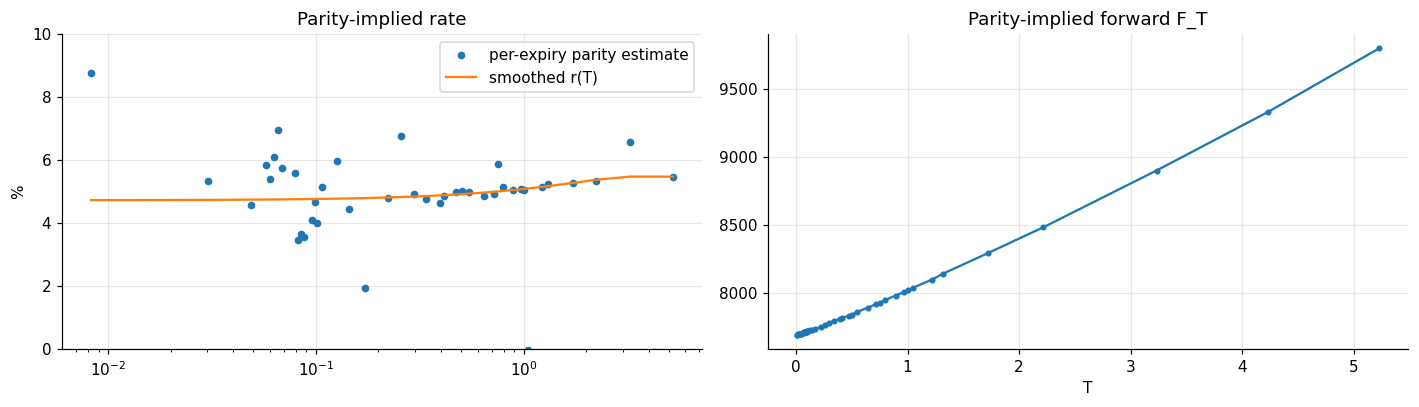

,T,D_raw,r_raw,r_curve,D,F
2026-10-01,0.0083,0.9993,0.0876,0.0473,0.9996,"7,692.7109"
2026-10-09,0.0302,0.9984,0.0535,0.0474,0.9986,"7,699.4206"
2026-10-19,0.0576,0.9966,0.0585,0.0475,0.9973,"7,704.9088"
2026-10-27,0.0795,0.9956,0.0559,0.0476,0.9962,"7,711.5804"
2026-11-04,0.1014,0.9960,0.0400,0.0477,0.9952,"7,719.0474"
2026-12-31,0.2576,0.9827,0.0678,0.0483,0.9876,"7,764.0381"
2027-03-31,0.5042,0.9749,0.0504,0.0492,0.9755,"7,842.6853"
2027-08-20,0.8925,0.9559,0.0506,0.0505,0.9559,"7,982.6785"
2028-06-16,1.7171,0.9135,0.0527,0.0528,0.9134,"8,293.5252"


In [3]:
def settle_time(root: str) -> pd.Timedelta:
    return pd.Timedelta(hours=9, minutes=30) if root == "SPX" else pd.Timedelta(hours=16)


def clean_chain(df: pd.DataFrame, min_T=3 / 365, max_rel_spread=0.5) -> pd.DataFrame:
    d = df.copy()
    d["root"] = d["contractSymbol"].str.extract(r"^([A-Z]+)")[0]
    major = d.groupby(["expiry", "root"]).size().reset_index().sort_values(0).drop_duplicates("expiry", keep="last")
    d = d.merge(major[["expiry", "root"]], on=["expiry", "root"])
    d["T"] = [(pd.Timestamp(e) + settle_time(r) - SNAP) / pd.Timedelta(days=365) for e, r in zip(d.expiry, d.root)]
    d["mid"] = 0.5 * (d["bid"] + d["ask"])
    d = d[(d["bid"] > 0) & (d["ask"] > d["bid"]) & (d["T"] >= min_T)]
    d = d[(d["ask"] - d["bid"]) / d["mid"] <= max_rel_spread]
    return d[["expiry", "root", "T", "type", "strike", "bid", "ask", "mid", "volume", "openInterest",
              "lastTradeDate"]].reset_index(drop=True)


def _cp_pairs(g: pd.DataFrame, n_strikes=15) -> pd.Series:
    c = g[g.type == "C"].set_index("strike")["mid"]
    p = g[g.type == "P"].set_index("strike")["mid"]
    both = (c - p).dropna()
    return both.loc[both.abs().nsmallest(n_strikes).index] if len(both) >= 5 else both.iloc[:0]


def forwards_and_discounts(q: pd.DataFrame, rate_fn=None):
    """Stage 1: robust per-expiry regression -> D_T. Stage 2: smooth r(T), then F_T.
    Pass `rate_fn` (T -> r) to reuse a rate curve from another underlying (e.g. for American SPY)."""
    raw_pts = {}
    for e, g in q.groupby("expiry"):
        cp = _cp_pairs(g)
        if len(cp) < 5:
            continue
        K = cp.index.values.astype(float); y = cp.values
        r = least_squares(lambda x: x[0] - x[1] * K - y, x0=[y.mean() + K.mean(), 1.0], loss="soft_l1",
                          f_scale=0.5)
        raw_pts[e] = dict(T=g["T"].iloc[0], D_raw=r.x[1])
    pts = pd.DataFrame(raw_pts).T.astype(float)
    pts["r_raw"] = -np.log(pts.D_raw.clip(1e-3)) / pts["T"]
    if rate_fn is None:
        use = pts[(pts["T"] > 0.05) & pts.r_raw.between(-0.05, 0.15)]
        coef = least_squares(lambda c: use["T"] ** 0.5 * (np.polyval(c, use["T"]) - use.r_raw), x0=[0, 0, 0.04],
                             loss="soft_l1", f_scale=0.005).x
        rate_fn = lambda T, c=coef: np.polyval(c, np.minimum(T, 3.0))
    pts["r_curve"] = rate_fn(pts["T"].values)
    pts["D"] = np.exp(-pts.r_curve * pts["T"])
    F = {}
    for e, g in q.groupby("expiry"):
        if e in pts.index:
            cp = _cp_pairs(g)
            F[e] = np.median(cp.index.values + cp.values / pts.loc[e, "D"])
    pts["F"] = pd.Series(F)
    return pts.dropna(), rate_fn


q = clean_chain(spx)
fwd, rate_curve = forwards_and_discounts(q)
print(f"{len(fwd)} usable expiries after cleaning")
fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].plot(fwd["T"], fwd.r_raw * 100, "o", ms=4, label="per-expiry parity estimate")
ax[0].plot(fwd["T"], fwd.r_curve * 100, "-", label="smoothed r(T)")
ax[0].set_ylim(0, 10); ax[0].set_xscale("log"); ax[0].set_ylabel("%"); ax[0].set_title("Parity-implied rate"); ax[0].legend()
ax[1].plot(fwd["T"], fwd.F, "o-", ms=3); ax[1].set_title("Parity-implied forward F_T"); ax[1].set_xlabel("T")
plt.tight_layout(); plt.show()
fwd.iloc[::6]

The raw per-expiry rates scatter widely at the short end (a cent of price noise divided by a tiny $T$) but
line up at longer maturities. The smoothed curve sits in the neighbourhood of the prevailing funding rate
(SOFR ≈ 3.9 % at the time of the snapshot) plus the small premium SPX box spreads usually carry. The forward
rises more slowly than $e^{rT}$ because of the index dividend yield. Both come out of the data with no
external inputs.

## 3. Implied-volatility inversion
We invert Black-76 with Brent's method on out-of-the-money options only (puts for $K<F$,
calls for $K\ge F$). OTM options carry all of the time value, and using them avoids the deep-ITM
quotes whose IV is extremely sensitive to the tiny intrinsic-value error.

In [4]:
def black76(F, K, T, sigma, D, is_call):
    sd = sigma * np.sqrt(T)
    d1 = (np.log(F / K) + 0.5 * sd * sd) / sd
    d2 = d1 - sd
    if is_call:
        return D * (F * norm.cdf(d1) - K * norm.cdf(d2))
    return D * (K * norm.cdf(-d2) - F * norm.cdf(-d1))


def implied_vol(price, F, K, T, D, is_call):
    intrinsic = D * max((F - K) if is_call else (K - F), 0.0)
    if not np.isfinite(price) or price <= intrinsic + 1e-10:
        return np.nan
    f = lambda s: black76(F, K, T, s, D, is_call) - price
    try:
        return brentq(f, 1e-4, 5.0, xtol=1e-8)
    except ValueError:
        return np.nan


def build_iv_table(q: pd.DataFrame, fwd: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for e, g in q.groupby("expiry"):
        if e not in fwd.index:
            continue
        F, D, T = fwd.loc[e, ["F", "D", "T"]]
        otm = g[((g.type == "P") & (g.strike < F)) | ((g.type == "C") & (g.strike >= F))]
        for r in otm.itertuples():
            is_call = r.type == "C"
            rows.append(dict(expiry=e, T=T, F=F, D=D, type=r.type, strike=r.strike, k=np.log(r.strike / F),
                             bid=r.bid, ask=r.ask, mid=r.mid, volume=r.volume,
                             iv_mid=implied_vol(r.mid, F, r.strike, T, D, is_call),
                             iv_bid=implied_vol(r.bid, F, r.strike, T, D, is_call),
                             iv_ask=implied_vol(r.ask, F, r.strike, T, D, is_call)))
    iv = pd.DataFrame(rows).dropna(subset=["iv_mid"])
    iv["w"] = iv["iv_mid"] ** 2 * iv["T"]
    return iv


t0 = time.time()
iv = build_iv_table(q, fwd)
iv = iv[(iv.k > -1.2) & (iv.k < 0.5)]         # keep a sensible moneyness band for fitting/plots
print(f"{len(iv):,} implied vols in {time.time() - t0:.1f}s")
iv.describe()[["T", "k", "iv_mid", "iv_bid", "iv_ask"]]

9,729 implied vols in 19.9s


,T,k,iv_mid,iv_bid,iv_ask
count,"9,729.0000","9,729.0000","9,729.0000","9,729.0000","9,729.0000"
mean,0.4223,-0.1157,0.2138,0.2129,0.2147
std,0.6022,0.2117,0.1067,0.1058,0.1075
min,0.0083,-1.1938,0.0839,0.0786,0.0891
25%,0.0631,-0.1845,0.1356,0.1351,0.1361
50%,0.2213,-0.0535,0.1787,0.1782,0.1794
75%,0.5473,0.0096,0.2582,0.2572,0.2592
max,5.2267,0.4900,0.7915,0.7819,0.8001


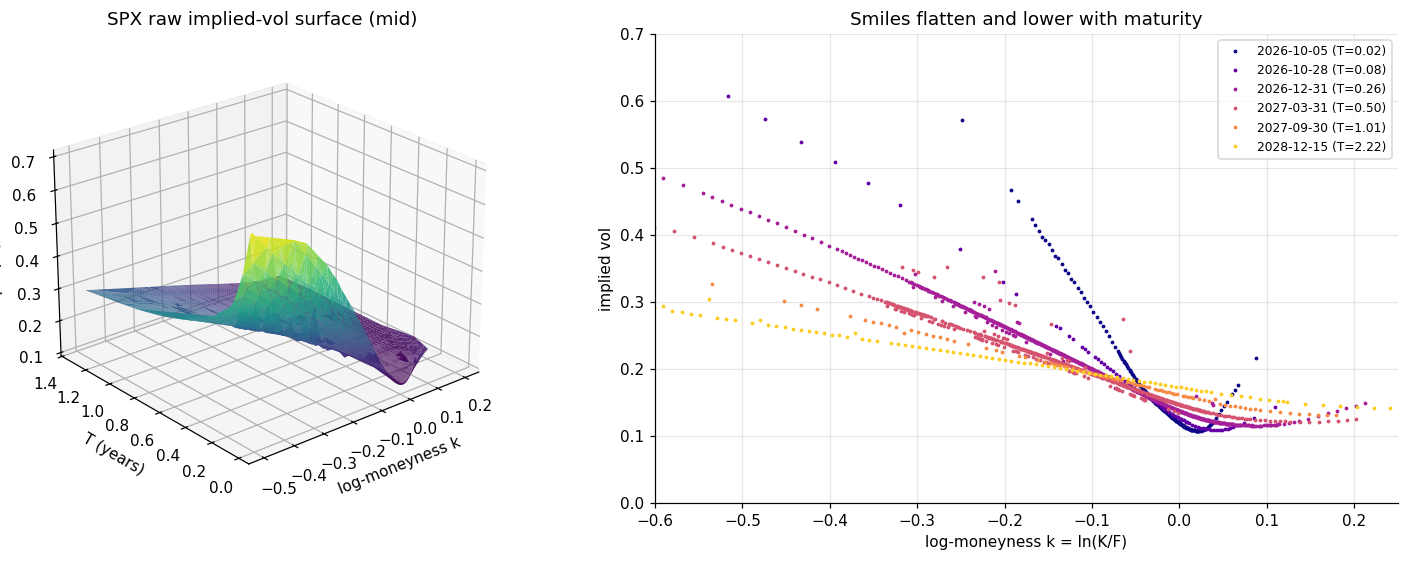

In [5]:
fig = plt.figure(figsize=(14, 5.2))
ax = fig.add_subplot(1, 2, 1, projection="3d")
s = iv[(iv["T"] < 1.6) & (iv["T"] > 0.02) & iv.k.between(-0.5, 0.2)]
ax.plot_trisurf(s["k"], s["T"], s["iv_mid"], cmap=cm.viridis, linewidth=0.1, antialiased=True, alpha=0.9)
ax.set_xlabel("log-moneyness k"); ax.set_ylabel("T (years)"); ax.set_zlabel("implied vol")
ax.set_title("SPX raw implied-vol surface (mid)"); ax.view_init(24, -130)

ax2 = fig.add_subplot(1, 2, 2)
exps = fwd.index[np.searchsorted(fwd["T"].values, [7/365, 30/365, 91/365, 182/365, 365/365, 730/365]).clip(0, len(fwd)-1)]
for e, c in zip(exps, plt.cm.plasma(np.linspace(0, .9, len(exps)))):
    g = iv[iv.expiry == e]
    ax2.plot(g["k"], g["iv_mid"], ".", ms=3, color=c, label=f"{e} (T={g['T'].iloc[0]:.2f})")
ax2.set_xlim(-0.6, 0.25); ax2.set_ylim(0, 0.7)
ax2.set_xlabel("log-moneyness k = ln(K/F)"); ax2.set_ylabel("implied vol"); ax2.legend(fontsize=8)
ax2.set_title("Smiles flatten and lower with maturity")
plt.tight_layout(); plt.show()

The shape is the familiar equity-index **skew**: implied vol rises steeply for low strikes
(crash protection is expensive), and the smile flattens as maturity grows. The ATM term structure
at the time of the snapshot slopes upward (VIX9D < VIX < VIX3M), the normal "calm-market" shape.

## 4. Model-free arbitrage detection on the raw quotes
Now we test the **quotes themselves**, before any model is fitted. For each expiry we check every
adjacent pair or triplet of OTM strikes (puts below the forward, calls above), within $-1\le k\le0.4$. Each check is run twice:

* **mid**: using mid prices (model-consistency check);
* **executable**: buy legs at the ask, sell legs at the bid. A violation here is a genuine,
  riskless profit before fees (if the quotes were simultaneous and firm).

Butterfly with unequal strike spacing $K_1<K_2<K_3$: with $\lambda=\frac{K_3-K_2}{K_3-K_1}$, the portfolio
$\lambda C_1 + (1-\lambda)C_3 - C_2$ pays $\ge 0$ in every state, so it must cost $\ge 0$.

Calendar: for zero rates and dividends, $C(K,T_2)\ge C(K,T_1)$. With carry, the correct invariant is the
**forward-normalised** price $c(k,T)=C/(D_T F_T)$ at fixed $k=\ln(K/F_T)$, which must be non-decreasing
in $T$. Strikes differ between expiries, so we interpolate $c$ linearly in $k$ inside each slice.

In [6]:
def check_vertical_butterfly(q: pd.DataFrame, fwd: pd.DataFrame, tol=1e-9, k_band=(-1.0, 0.4)) -> pd.DataFrame:
    out = []
    for (e, typ), g in q.groupby(["expiry", "type"]):
        if e not in fwd.index:
            continue
        F, D = fwd.loc[e, ["F", "D"]]
        # OTM quotes only, inside a sane moneyness band (see §2.2 on stale ITM quotes)
        g = g[(g.strike >= F) if typ == "C" else (g.strike < F)]
        g = g[np.log(g.strike / F).between(k_band[0], k_band[1])].sort_values("strike")
        K, b, a, m = (g[c].values.astype(float) for c in ("strike", "bid", "ask", "mid"))
        for i in range(len(K) - 1):
            # vertical: long the more expensive strike must cost >= 0 and <= D*dK
            lo, hi = (i, i + 1) if typ == "C" else (i + 1, i)
            dK = K[i + 1] - K[i]
            out.append(dict(expiry=e, type=typ, check="vertical", K=K[i],
                            mid_viol=(m[lo] - m[hi] < -tol) or (m[lo] - m[hi] > D * dK + tol),
                            exec_viol=(a[lo] - b[hi] < -tol) or (b[lo] - a[hi] > D * dK + tol),
                            exec_edge=max(b[hi] - a[lo], b[lo] - a[hi] - D * dK)))
        for i in range(len(K) - 2):
            lam = (K[i + 2] - K[i + 1]) / (K[i + 2] - K[i])
            mid_cost = lam * m[i] + (1 - lam) * m[i + 2] - m[i + 1]
            exec_cost = lam * a[i] + (1 - lam) * a[i + 2] - b[i + 1]
            out.append(dict(expiry=e, type=typ, check="butterfly", K=K[i + 1],
                            mid_viol=mid_cost < -tol, exec_viol=exec_cost < -tol, exec_edge=-exec_cost))
    return pd.DataFrame(out).merge(fwd[["T", "F"]], left_on="expiry", right_index=True)


def check_calendar(q: pd.DataFrame, fwd: pd.DataFrame, k_grid=np.linspace(-0.3, 0.1, 41)) -> pd.DataFrame:
    """Forward-normalised OTM prices c(k,T) = price/(D F) must be non-decreasing in T at fixed k."""
    sl = {}
    for e, g in q.groupby("expiry"):
        if e not in fwd.index:
            continue
        F, D = fwd.loc[e, ["F", "D"]]
        otm = g[((g.type == "P") & (g.strike < F)) | ((g.type == "C") & (g.strike >= F))].sort_values("strike")
        k = np.log(otm.strike.values / F)
        if len(k) < 8 or k.min() > k_grid.min() or k.max() < k_grid.max():
            continue
        norm_ = lambda x: np.interp(k_grid, k, x / (D * F))
        sl[e] = dict(T=fwd.loc[e, "T"], bid=norm_(otm.bid.values), ask=norm_(otm.ask.values), mid=norm_(otm.mid.values))
    es = sorted(sl, key=lambda e: sl[e]["T"])
    out = []
    for e1, e2 in zip(es[:-1], es[1:]):
        s1, s2 = sl[e1], sl[e2]
        for j, kk in enumerate(k_grid):
            out.append(dict(e1=e1, e2=e2, T1=s1["T"], k=kk,
                            mid_viol=s2["mid"][j] < s1["mid"][j] - 1e-9,
                            exec_viol=s2["ask"][j] < s1["bid"][j] - 1e-9,
                            exec_edge=s1["bid"][j] - s2["ask"][j]))
    return pd.DataFrame(out)


vb = check_vertical_butterfly(q, fwd)
cal = check_calendar(q, fwd)
summary = pd.concat([
    vb.groupby("check")[["mid_viol", "exec_viol"]].agg(["sum", "count"]),
    pd.DataFrame({("mid_viol", "sum"): [cal.mid_viol.sum()], ("mid_viol", "count"): [len(cal)],
                  ("exec_viol", "sum"): [cal.exec_viol.sum()], ("exec_viol", "count"): [len(cal)]},
                 index=["calendar"])])
summary.columns = ["mid violations", "checks", "executable violations", "checks_"]
summary = summary.drop(columns="checks_")
summary["mid rate"] = summary["mid violations"] / summary["checks"]
summary["exec rate"] = summary["executable violations"] / summary["checks"]
summary

,mid violations,checks,executable violations,mid rate,exec rate
butterfly,2670,9435,234,0.2830,0.0248
vertical,290,9541,266,0.0304,0.0279
calendar,14,1394,10,0.0100,0.0072


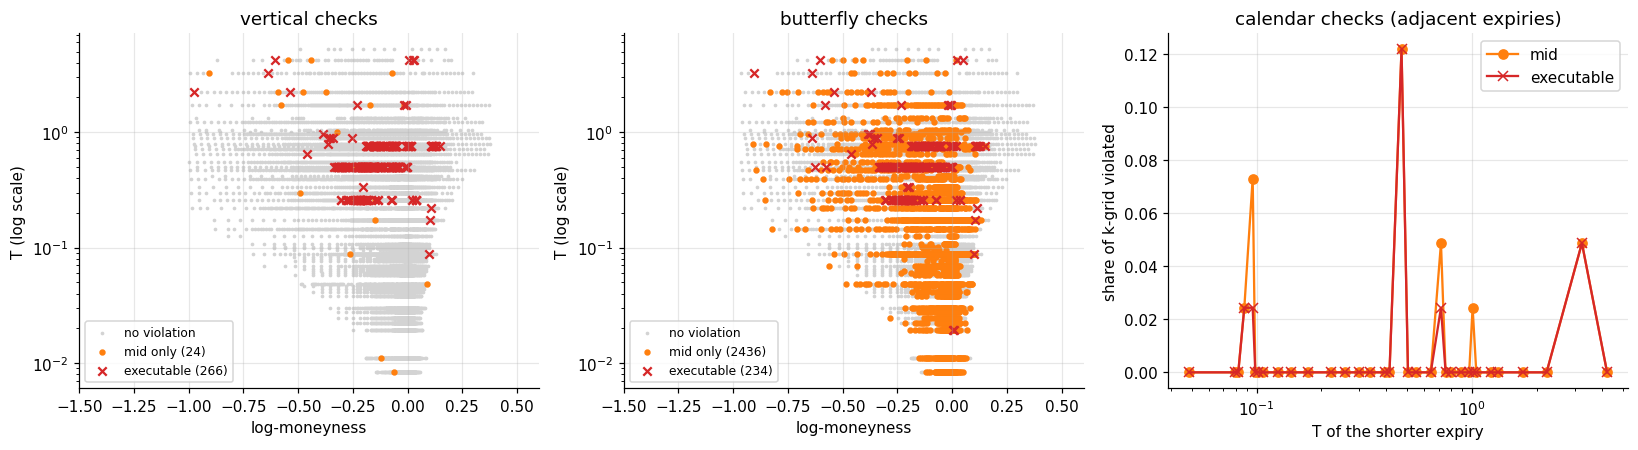

Largest executable edges (price units):


,expiry,type,check,K,F,exec_edge
18862,2030-12-20,C,vertical,"9,550.0000","9,333.2017",446.5393
18863,2030-12-20,C,vertical,"9,600.0000","9,333.2017",384.7000
13992,2027-03-31,P,butterfly,"7,355.0000","7,842.6853",188.2500
13587,2027-03-31,P,vertical,"7,355.0000","7,842.6853",187.3000
13586,2027-03-31,P,vertical,"7,350.0000","7,842.6853",184.3226
18871,2030-12-20,C,butterfly,"9,550.0000","9,333.2017",148.7000
18873,2030-12-20,C,butterfly,"9,800.0000","9,333.2017",145.8500
13598,2027-03-31,P,vertical,"7,410.0000","7,842.6853",120.3226


In [7]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4.2))
for ax, chk in zip(axs[:2], ["vertical", "butterfly"]):
    d = vb[vb.check == chk]
    ok = d[~d.mid_viol]
    ax.scatter(np.log(ok.K / ok.F), ok["T"], s=2, c="lightgrey", label="no violation")
    mv = d[d.mid_viol & ~d.exec_viol]
    ax.scatter(np.log(mv.K / mv.F), mv["T"], s=10, c="tab:orange", label=f"mid only ({len(mv)})")
    ev = d[d.exec_viol]
    ax.scatter(np.log(ev.K / ev.F), ev["T"], s=30, c="tab:red", marker="x", label=f"executable ({len(ev)})")
    ax.set_yscale("log"); ax.set_xlim(-1.5, 0.6); ax.set_xlabel("log-moneyness"); ax.set_ylabel("T (log scale)")
    ax.set_title(f"{chk} checks"); ax.legend(fontsize=8)
c2 = cal.groupby("T1")[["mid_viol", "exec_viol"]].mean()
axs[2].plot(c2.index, c2.mid_viol, "o-", label="mid", color="tab:orange")
axs[2].plot(c2.index, c2.exec_viol, "x-", label="executable", color="tab:red")
axs[2].set_xscale("log"); axs[2].set_xlabel("T of the shorter expiry"); axs[2].set_ylabel("share of k-grid violated")
axs[2].set_title("calendar checks (adjacent expiries)"); axs[2].legend()
plt.tight_layout(); plt.show()

print("Largest executable edges (price units):")
vb[vb.exec_viol].sort_values("exec_edge", ascending=False).head(8)[["expiry", "type", "check", "K", "F", "exec_edge"]]

**Reading the diagnostics.**
* Violations on **mid** cluster in the far wings and at the longest maturities, where quotes are wide, stale
  and strikes are sparse. At the mid, a wide bid-ask can easily make a butterfly look like it has negative cost.
* **Executable** violations are rare. When they appear, they are typically a few cents on deep-OTM
  strikes with tiny size — well inside exchange fees and the risk that the quote is no longer there.
* Some apparent violations are **artefacts of the data**, not arbitrage: Yahoo's quotes are not
  synchronous (the chain is pulled expiry by expiry over a minute or two while the index moves) and
  AM- vs PM-settled contracts with nearby expiry dates have slightly different payoffs. This is the
  everyday reality of arbitrage monitoring: most alerts are data problems, so a monitor must
  report *why* a point is flagged and how large the edge is relative to the spread.

### 4.1 Unit test: does the detector catch an injected arbitrage?
A detector that never fires might just be broken. We corrupt one quote so that a butterfly is
executable at a profit and confirm that exactly that strike is flagged.

In [8]:
e_test = fwd.index[np.argmin(abs(fwd["T"] - 0.25))]
qq = q.copy()
g = qq[(qq.expiry == e_test) & (qq.type == "C")].sort_values("strike")
F_t = fwd.loc[e_test, "F"]
i_mid = g[g.strike > F_t].index[2]            # an OTM call with OTM neighbours on both sides
qq.loc[i_mid, ["bid", "ask", "mid"]] += 25.0          # overprice the body of a butterfly
vb_t = check_vertical_butterfly(qq[qq.expiry == e_test], fwd)
hits = vb_t[(vb_t.check == "butterfly") & vb_t.exec_viol & (vb_t.type == "C")]
print(f"expiry {e_test}: injected +25 at K={qq.loc[i_mid, 'strike']:.0f}; "
      f"flagged butterflies centred at: {hits.K.tolist()}")

expiry 2026-12-31: injected +25 at K=7775; flagged butterflies centred at: [7775.0, 7915.0, 8055.0, 8065.0]


### 4.2 Most "executable arbitrage" is stale quotes
The executable flags above are concentrated in a handful of expiries (the quarter-end contracts in
particular), with edges of tens or hundreds of index points, far too large to be real in the most
liquid options market in the world. The vendor's quote for an untraded contract can be hours or days old.
The most useful filter in practice is quote **freshness**. We don't have quote timestamps, so we use
the last-trade time as a proxy and keep only contracts that traded on the snapshot day.

In [9]:
fresh = q[q.lastTradeDate >= pd.Timestamp("2026-09-28 13:30", tz="UTC")]
vb_f = check_vertical_butterfly(fresh, fwd)
pd.DataFrame({
    "all quotes: exec violations": vb.groupby("check").exec_viol.sum(),
    "all quotes: checks": vb.groupby("check").size(),
    "traded today: exec violations": vb_f.groupby("check").exec_viol.sum(),
    "traded today: checks": vb_f.groupby("check").size(),
    "traded today: max edge": vb_f[vb_f.exec_viol].groupby("check").exec_edge.max()}).fillna(0)

,all quotes: exec violations,all quotes: checks,traded today: exec violations,traded today: checks,traded today: max edge
check,,,,,
butterfly,234,9435,2,4582,0.0500
vertical,266,9541,0,4684,0.0000


With the freshness filter the executable count collapses. What is left are one- or two-tick edges
that disappear once you add fees and the fact that the legs of a butterfly were not quoted at the same
instant. This is the realistic conclusion: **SPX is free of static arbitrage to within transaction costs**.
The value of the detector is as a *data-quality* and *model-sanity* tool, and as a fast alarm for the rare
moment (a fat-finger quote, a market-maker outage) when it isn't.

## 5. SVI slice fits

Gatheral's **raw SVI** ("stochastic volatility inspired") parameterisation of one smile is
$$w(k)=a+b\Big(\rho\,(k-m)+\sqrt{(k-m)^2+\sigma^2}\Big).$$
* $a$ sets the level, $b$ the angle between the wings, $\rho$ the skew/rotation, $m$ a horizontal shift, and
  $\sigma$ the ATM curvature;
* the wings are asymptotically linear in $k$, consistent with Roger Lee's moment formula
  ($w(k)\le 2|k|$ for large $|k|$);
* it fits equity smiles remarkably well with 5 parameters, but **nothing in the parameterisation
  prevents butterfly or calendar arbitrage**, so we must check it.

We fit each slice by weighted least squares on total variance. Weights are proportional to $1/\text{(bid–ask
spread in vol)}$, so a liquid ATM quote counts for more than a wide wing quote. Parameters are
bounded ($b\ge0$, $|\rho|<1$, $\sigma>0$), and we add the minimum-variance constraint
$a+b\sigma\sqrt{1-\rho^2}\ge0$ as a penalty.

In [10]:
def svi_w(p, k):
    a, b, rho, m, sig = p
    return a + b * (rho * (k - m) + np.sqrt((k - m) ** 2 + sig ** 2))


def svi_derivs(p, k):
    a, b, rho, m, sig = p
    r = np.sqrt((k - m) ** 2 + sig ** 2)
    w = a + b * (rho * (k - m) + r)
    w1 = b * (rho + (k - m) / r)
    w2 = b * sig ** 2 / r ** 3
    return w, w1, w2


def durrleman_g(p, k):
    w, w1, w2 = svi_derivs(p, k)
    return (1 - k * w1 / (2 * w)) ** 2 - w1 ** 2 / 4 * (1 / w + 0.25) + w2 / 2


def fit_svi(k, w, wt, T):
    def resid(p):
        a, b, rho, m, sig = p
        pen = max(0.0, -(a + b * sig * np.sqrt(1 - rho ** 2))) * 1e3
        return np.append(wt * (svi_w(p, k) - w), pen)
    best = None
    atm = np.interp(0, k, w) if k.min() < 0 < k.max() else np.median(w)
    for rho0 in (-0.7, -0.3, 0.0):
        for sig0 in (0.05, 0.2):
            x0 = [atm * 0.5, 0.1, rho0, 0.0, sig0]
            r = least_squares(resid, x0, bounds=([-1, 1e-6, -0.999, -1, 1e-4], [1, 5, 0.999, 1, 2]),
                              x_scale="jac", max_nfev=4000)
            if best is None or r.cost < best.cost:
                best = r
    return best.x


svi = {}
for e, g in iv.groupby("expiry"):
    g = g[(g.k > -0.8) & (g.k < 0.3)].sort_values("k")
    if len(g) < 10:
        continue
    T = g["T"].iloc[0]
    spread_w = np.maximum((g.iv_ask - g.iv_bid).fillna(0.05).values, 0.002) * 2 * g.iv_mid.values * T
    wt = 1 / spread_w
    p = fit_svi(g.k.values, g.w.values, wt / wt.mean(), T)
    fit_iv = np.sqrt(np.maximum(svi_w(p, g.k.values), 1e-12) / T)
    kk = np.linspace(-1.0, 0.5, 601)
    svi[e] = dict(T=T, params=p,
                  rmse_volpts=100 * np.sqrt(np.mean((fit_iv - g.iv_mid.values) ** 2)),
                  in_spread=np.mean((fit_iv >= g.iv_bid.values - 1e-4) & (fit_iv <= g.iv_ask.values + 1e-4)),
                  min_g=durrleman_g(p, kk).min(), atm_w=svi_w(p, 0.0))
svi_tab = pd.DataFrame(svi).T.sort_values("T")
svi_tab[["T", "rmse_volpts", "in_spread", "min_g", "atm_w"]].astype(float).iloc[::4]

,T,rmse_volpts,in_spread,min_g,atm_w
2026-10-01,0.0083,0.6058,0.2204,-0.0112,0.0001
2026-10-07,0.0247,0.4145,0.2471,-0.0015,0.0004
2026-10-13,0.0412,0.2011,0.2893,0.0423,0.0006
2026-10-19,0.0576,0.1925,0.3280,0.0603,0.0008
2026-10-23,0.0686,0.2175,0.3235,0.0685,0.0011
2026-10-29,0.0850,0.0607,0.5323,0.0810,0.0014
2026-11-04,0.1014,0.0832,0.8125,0.0874,0.0018
2026-11-30,0.1727,0.1751,0.4339,-0.0421,0.0031
2027-01-29,0.3371,0.1707,0.1542,-0.0355,0.0068
2027-03-31,0.5042,1.2140,0.1652,0.1297,0.0110


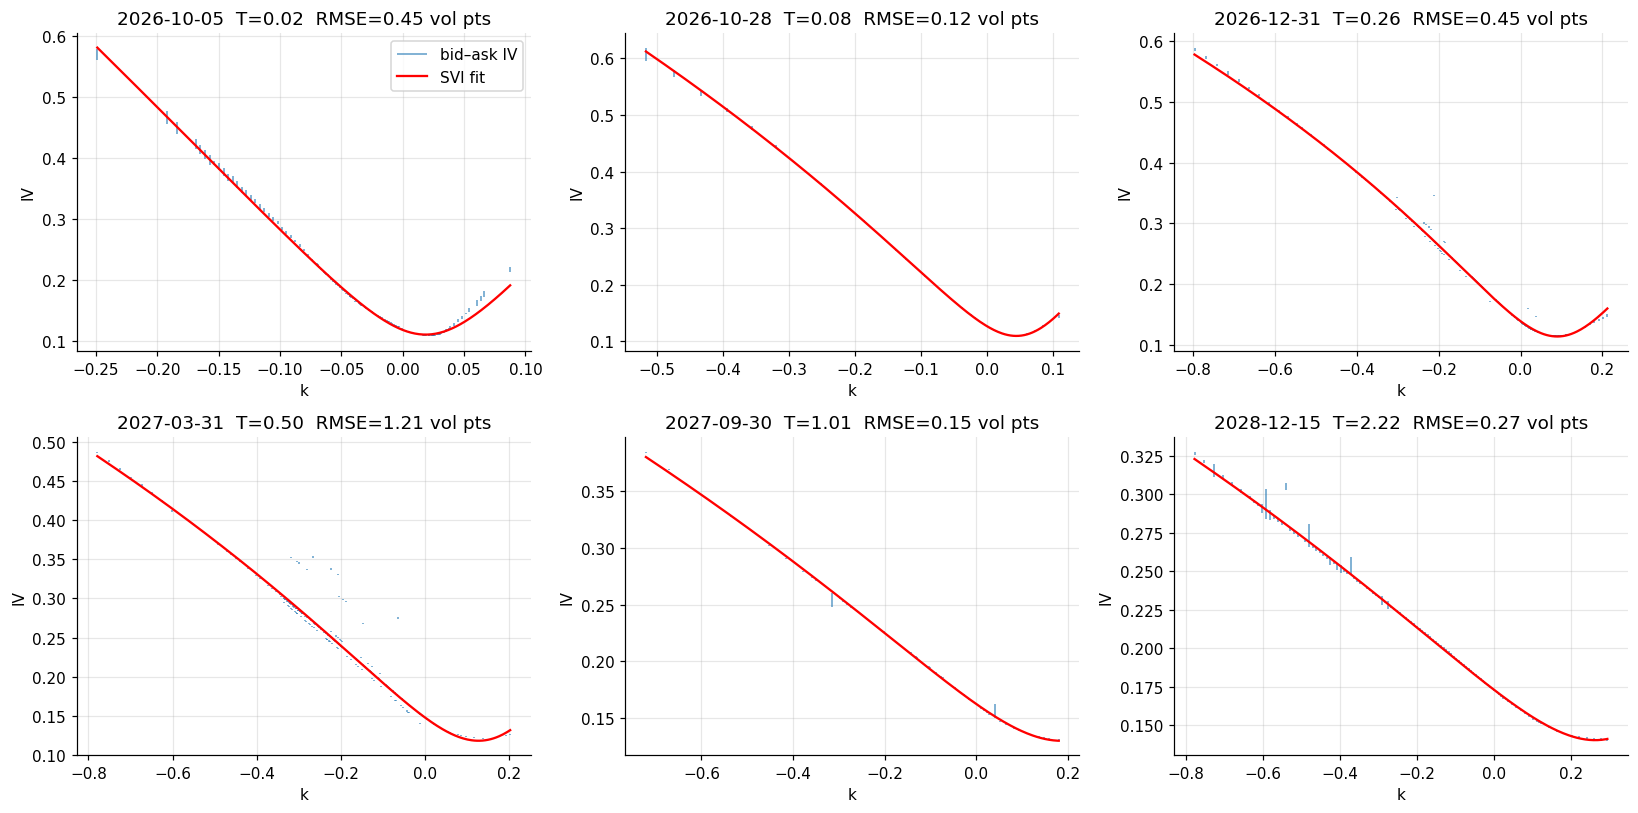

In [11]:
show = [e for e in exps if e in svi]
fig, axs = plt.subplots(2, 3, figsize=(15, 7.5))
for ax, e in zip(axs.ravel(), show):
    g = iv[(iv.expiry == e) & (iv.k > -0.8) & (iv.k < 0.3)].sort_values("k")
    T = svi[e]["T"]; p = svi[e]["params"]
    kk = np.linspace(g.k.min(), g.k.max(), 300)
    ax.vlines(g.k, g.iv_bid, g.iv_ask, color="tab:blue", alpha=0.6, lw=1.2, label="bid–ask IV")
    ax.plot(kk, np.sqrt(svi_w(p, kk) / T), "r-", lw=1.5, label="SVI fit")
    ax.set_title(f"{e}  T={T:.2f}  RMSE={svi[e]['rmse_volpts']:.2f} vol pts")
    ax.set_xlabel("k"); ax.set_ylabel("IV")
axs[0, 0].legend(); plt.tight_layout(); plt.show()

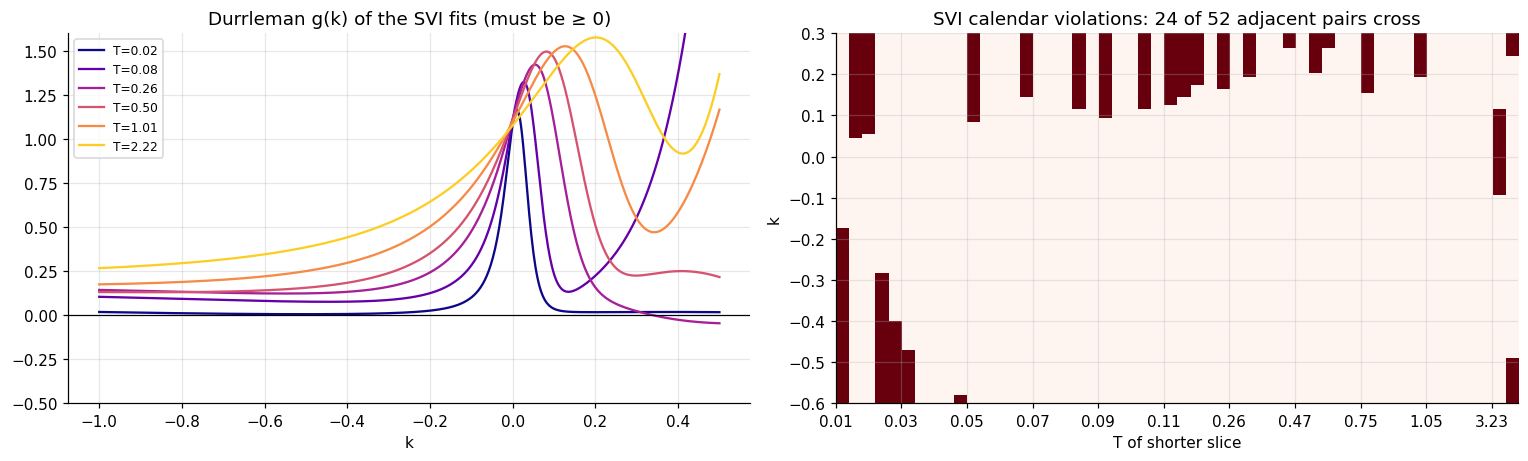

slices with butterfly arbitrage (min g < 0): 15 of 53


In [12]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.3))
kk = np.linspace(-1.0, 0.5, 601)
for e, c in zip(show, plt.cm.plasma(np.linspace(0, .9, len(show)))):
    axs[0].plot(kk, durrleman_g(svi[e]["params"], kk), color=c, label=f"T={svi[e]['T']:.2f}")
axs[0].axhline(0, color="k", lw=0.8); axs[0].set_ylim(-0.5, 1.6)
axs[0].set_title("Durrleman g(k) of the SVI fits (must be ≥ 0)"); axs[0].set_xlabel("k"); axs[0].legend(fontsize=8)

# calendar check on the fitted slices: w_{T_{i+1}}(k) >= w_{T_i}(k) on a grid
es = list(svi_tab.index)
kg = np.linspace(-0.6, 0.3, 91)
Wm = np.array([svi_w(svi[e]["params"], kg) for e in es])
cal_bad = (np.diff(Wm, axis=0) < -1e-6)
im = axs[1].imshow(cal_bad.T, aspect="auto", origin="lower", cmap="Reds",
                   extent=[0, len(es) - 1, kg[0], kg[-1]])
axs[1].set_xticks(range(0, len(es) - 1, 5)); axs[1].set_xticklabels([f"{svi[es[i]]['T']:.2f}" for i in range(0, len(es) - 1, 5)])
axs[1].set_xlabel("T of shorter slice"); axs[1].set_ylabel("k")
axs[1].set_title(f"SVI calendar violations: {cal_bad.any(axis=1).sum()} of {len(es)-1} adjacent pairs cross")
plt.tight_layout(); plt.show()
print(f"slices with butterfly arbitrage (min g < 0): {(svi_tab.min_g.astype(float) < 0).sum()} of {len(svi_tab)}")

Independent slice fits are excellent inside the bid–ask spread, but **they are not a surface**.
Neighbouring slices are fitted independently, so their total-variance curves can cross (calendar
arbitrage), and a slice can develop a region with $g(k)<0$ when the fit bends to chase a noisy wing.
Downstream (local-vol, exotic pricing, risk-neutral densities) these defects become negative
probabilities or local variances. Two standard fixes:
1. constrain each SVI fit so that $g\ge0$ and it lies above the previous slice (Gatheral–Jacquier's
   "arbitrage-free SVI" algorithm), or
2. use a surface parameterisation that is arbitrage-free **by construction**, which is SSVI.

## 6. SSVI — Surface SVI (Gatheral & Jacquier, 2014)
$$w(k,\theta_T)=\frac{\theta_T}{2}\Big(1+\rho\,\varphi(\theta_T)k+\sqrt{(\varphi(\theta_T)k+\rho)^2+1-\rho^2}\Big),\qquad
\varphi(\theta)=\frac{\eta}{\theta^{\gamma}(1+\theta)^{1-\gamma}}.$$
* $\theta_T$ = ATM total variance, read from the market (the SVI fits at $k=0$) and made **non-decreasing** in $T$
  with isotonic regression, which is necessary for calendar-no-arbitrage.
* Only **three** parameters ($\rho,\eta,\gamma$) shape the whole surface.
* **Theorem (G&J 2014, Rem. 4.4 / Cor. 4.1):** with the power-law $\varphi$, the surface is free of
  static arbitrage if $\theta_T$ is non-decreasing, $0<\gamma\le\tfrac12$ and $\eta(1+|\rho|)\le 2$.

We impose exactly these constraints in the optimiser. The price is a worse fit, and the size of that
price is the interesting number.

In [13]:
th_T = svi_tab["T"].astype(float).values
th_raw = svi_tab["atm_w"].astype(float).values
theta = IsotonicRegression(increasing=True).fit_transform(th_T, th_raw)
theta_map = dict(zip(svi_tab.index, theta))


def ssvi_w(k, th, rho, eta, gam):
    phi = eta / (th ** gam * (1 + th) ** (1 - gam))
    return th / 2 * (1 + rho * phi * k + np.sqrt((phi * k + rho) ** 2 + 1 - rho ** 2))


fit_set = iv[iv.expiry.isin(svi_tab.index) & (iv.k > -0.8) & (iv.k < 0.3)].copy()
fit_set["theta"] = fit_set.expiry.map(theta_map)
spread_vol = np.maximum((fit_set.iv_ask - fit_set.iv_bid).fillna(0.05).values, 0.002)
wt_ssvi = 1 / spread_vol
# normalise so that every expiry carries the same total weight (otherwise the dense short-dated
# weeklies, with hundreds of strikes each, dominate the three global parameters)
wt_ssvi = wt_ssvi / fit_set.groupby("expiry")["k"].transform("size").values
wt_ssvi = np.sqrt(wt_ssvi / wt_ssvi.mean())


def ssvi_obj(x):
    rho, eta, gam = x
    wmod = ssvi_w(fit_set.k.values, fit_set.theta.values, rho, eta, gam)
    ivm = np.sqrt(np.maximum(wmod, 1e-12) / fit_set["T"].values)
    return np.mean((wt_ssvi * (ivm - fit_set.iv_mid.values)) ** 2)


cons = [{"type": "ineq", "fun": lambda x: 2 - x[1] * (1 + abs(x[0]))}]
res = minimize(ssvi_obj, x0=[-0.7, 1.0, 0.4], method="SLSQP", constraints=cons,
               bounds=[(-0.999, 0.999), (1e-3, 5), (1e-3, 0.5)])
rho_s, eta_s, gam_s = res.x
print(f"SSVI: rho={rho_s:.3f} eta={eta_s:.3f} gamma={gam_s:.3f}   eta(1+|rho|)={eta_s*(1+abs(rho_s)):.3f} (<=2)")

fit_set["iv_ssvi"] = np.sqrt(ssvi_w(fit_set.k, fit_set.theta, rho_s, eta_s, gam_s) / fit_set["T"])
fit_set["iv_svi"] = [np.sqrt(max(svi_w(svi[e]["params"], k), 1e-12) / T)
                     for e, k, T in zip(fit_set.expiry, fit_set.k, fit_set["T"])]
cmp = pd.DataFrame({
    m: {"RMSE (vol pts)": 100 * np.sqrt(np.mean((fit_set[c] - fit_set.iv_mid) ** 2)),
        "share inside bid-ask": np.mean((fit_set[c] >= fit_set.iv_bid - 1e-4) & (fit_set[c] <= fit_set.iv_ask + 1e-4)),
        "free parameters": n}
    for m, c, n in [("SVI per slice", "iv_svi", 5 * len(svi_tab)), ("SSVI surface", "iv_ssvi", 3 + len(svi_tab))]})
cmp

SSVI: rho=-0.711 eta=1.018 gamma=0.500   eta(1+|rho|)=1.742 (<=2)


,SVI per slice,SSVI surface
RMSE (vol pts),0.4203,2.8674
share inside bid-ask,0.3118,0.0282
free parameters,265.0000,56.0000


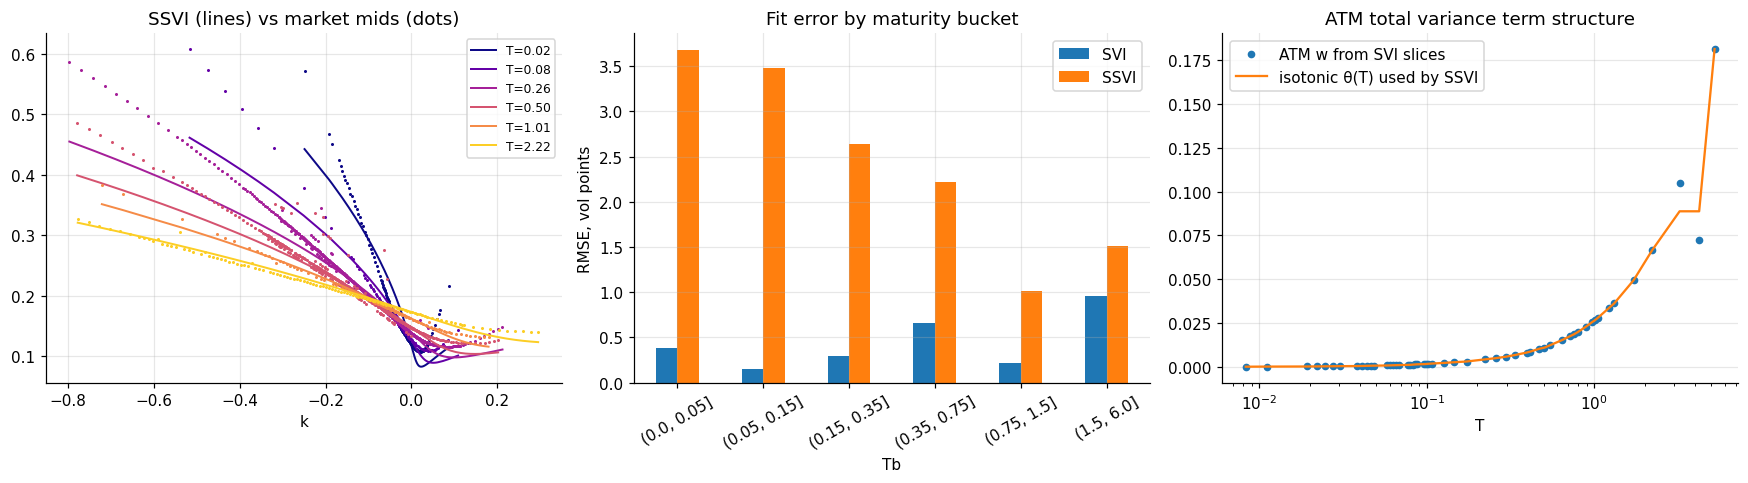

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
for e, c in zip(show, plt.cm.plasma(np.linspace(0, .9, len(show)))):
    g = fit_set[fit_set.expiry == e].sort_values("k")
    axs[0].plot(g.k, g.iv_mid, ".", ms=2, color=c)
    axs[0].plot(g.k, g.iv_ssvi, "-", color=c, lw=1.3, label=f"T={g['T'].iloc[0]:.2f}")
axs[0].set_title("SSVI (lines) vs market mids (dots)"); axs[0].set_xlabel("k"); axs[0].legend(fontsize=8)
err = fit_set.assign(Tb=pd.cut(fit_set["T"], [0, .05, .15, .35, .75, 1.5, 6]))
eb = err.groupby("Tb").apply(lambda d: pd.Series({"SVI": 100*np.sqrt(np.mean((d.iv_svi-d.iv_mid)**2)),
                                                  "SSVI": 100*np.sqrt(np.mean((d.iv_ssvi-d.iv_mid)**2))}))
eb.plot.bar(ax=axs[1]); axs[1].set_ylabel("RMSE, vol points"); axs[1].set_title("Fit error by maturity bucket")
axs[1].tick_params(axis="x", rotation=30)
axs[2].plot(th_T, th_raw, "o", ms=4, label="ATM w from SVI slices")
axs[2].plot(th_T, theta, "-", label="isotonic θ(T) used by SSVI")
axs[2].set_xscale("log"); axs[2].set_title("ATM total variance term structure"); axs[2].legend(); axs[2].set_xlabel("T")
plt.tight_layout(); plt.show()

### 6.1 eSSVI — one $(\rho_i,\psi_i)$ per slice, still arbitrage-free
The global SSVI can't produce the very steep short-dated SPX skew: at small $T$ the butterfly bound
$\eta(1+|\rho|)\le2$ caps the ATM skew. The **extended SSVI** (Hendriks & Martini 2019; Corbetta et al. 2019)
gives each slice its own correlation $\rho_i$ and skew scale $\psi_i=\theta_i\varphi_i$:
$$w_i(k)=\frac{\theta_i}{2}\Big(1+\rho_i\frac{\psi_i}{\theta_i}k+\sqrt{\Big(\frac{\psi_i}{\theta_i}k+\rho_i\Big)^2+1-\rho_i^2}\Big).$$
Sufficient no-arbitrage conditions that we enforce slice by slice, in maturity order:
* **butterfly** (per slice): $\psi_i(1+|\rho_i|)\le 4$ and $\psi_i^2(1+|\rho_i|)\le 4\theta_i$;
* **calendar** (consecutive slices): $\theta_{i}\ge\theta_{i-1}$ (isotonic θ), and
  $|\rho_i\psi_i-\rho_{i-1}\psi_{i-1}|\le\psi_i-\psi_{i-1}$, which says both asymptotic wing slopes
  $(1\pm\rho)\psi/2$ are non-decreasing in $T$. That is necessary but, when two θ's tie, not sufficient, so we
  also impose $w_i(k)\ge w_{i-1}(k)$ directly on a 61-point $k$-grid (and verify on a 1 501-point grid afterwards).

Two parameters per slice (plus θ from the market) are still far fewer than SVI's five, and the surface
is still arbitrage-free by construction.

In [15]:
def essvi_w(k, th, rho, psi):
    return th / 2 * (1 + rho * psi / th * k + np.sqrt((psi / th * k + rho) ** 2 + 1 - rho ** 2))


essvi = {}
rho_p, psi_p = 0.0, 0.0
k_cal = np.linspace(-1.0, 0.5, 61)                        # grid on which no-crossing is enforced
w_prev = np.zeros_like(k_cal)
for e in svi_tab.index:                                   # maturity order
    g = fit_set[fit_set.expiry == e]
    th, T = theta_map[e], g["T"].iloc[0]
    wv = 1 / np.maximum((g.iv_ask - g.iv_bid).fillna(0.05).values, 0.002)
    obj = lambda x: np.mean((wv / wv.mean()) * (np.sqrt(essvi_w(g.k.values, th, x[0], x[1]) / T) - g.iv_mid.values) ** 2) * 1e4
    cons = [{"type": "ineq", "fun": lambda x: 4 - x[1] * (1 + x[0])},
            {"type": "ineq", "fun": lambda x: 4 - x[1] * (1 - x[0])},
            {"type": "ineq", "fun": lambda x: 4 * th - x[1] ** 2 * (1 + x[0])},
            {"type": "ineq", "fun": lambda x: 4 * th - x[1] ** 2 * (1 - x[0])},
            {"type": "ineq", "fun": lambda x, a=rho_p, b=psi_p: (x[1] - b) - (x[0] * x[1] - a * b)},
            {"type": "ineq", "fun": lambda x, a=rho_p, b=psi_p: (x[1] - b) + (x[0] * x[1] - a * b)},
            {"type": "ineq", "fun": lambda x, wp=w_prev: essvi_w(k_cal, th, x[0], x[1]) - wp}]
    best = None
    for r0 in (-0.9, -0.6, -0.3):
        x0 = [r0, max(psi_p * 1.05, np.sqrt(th) * 0.5, 1e-4)]
        r = minimize(obj, x0, method="SLSQP", constraints=cons, bounds=[(-0.999, 0.999), (1e-6, 4)],
                     options={"maxiter": 500, "ftol": 1e-12})
        if r.success and (best is None or r.fun < best.fun):
            best = r
    if best is None:                          # fall back to the previous slice's shape (always feasible)
        best = type("R", (), {"x": np.array([rho_p, psi_p])})
    essvi[e] = best.x
    rho_p, psi_p = best.x
    w_prev = essvi_w(k_cal, th, rho_p, psi_p)

fit_set["iv_essvi"] = [np.sqrt(essvi_w(k, theta_map[e], *essvi[e]) / T) for e, k, T in
                       zip(fit_set.expiry, fit_set.k, fit_set["T"])]
cmp["eSSVI surface"] = {"RMSE (vol pts)": 100 * np.sqrt(np.mean((fit_set.iv_essvi - fit_set.iv_mid) ** 2)),
                        "share inside bid-ask": np.mean((fit_set.iv_essvi >= fit_set.iv_bid - 1e-4) &
                                                        (fit_set.iv_essvi <= fit_set.iv_ask + 1e-4)),
                        "free parameters": 3 * len(svi_tab)}

# verify: butterfly (Durrleman g >= 0 via finite differences) and calendar (no crossing) on a grid
kg = np.linspace(-1.0, 0.5, 1501); h = kg[1] - kg[0]
def g_numeric(wk):
    w1 = np.gradient(wk, h); w2 = np.gradient(w1, h)
    return (1 - kg * w1 / (2 * wk)) ** 2 - w1 ** 2 / 4 * (1 / wk + 0.25) + w2 / 2
We = np.array([essvi_w(kg, theta_map[e], *essvi[e]) for e in svi_tab.index])
print("eSSVI  min g(k) over all slices:", round(min(g_numeric(w)[5:-5].min() for w in We), 5),
      "| calendar: points with w_i < w_(i-1):", int((np.diff(We, axis=0) < -1e-10).sum()),
      f"| deepest crossing (total variance): {min(np.diff(We, axis=0).min(), 0):.1e}",
      f"(vs typical ATM w {np.median(list(theta_map.values())):.1e})")
cmp

eSSVI  min g(k) over all slices: 0.25273 | calendar: points with w_i < w_(i-1): 24 | deepest crossing (total variance): -3.6e-05 (vs typical ATM w 2.3e-03)


,SVI per slice,SSVI surface,eSSVI surface
RMSE (vol pts),0.4203,2.8674,2.1385
share inside bid-ask,0.3118,0.0282,0.0625
free parameters,265.0000,56.0000,159.0000


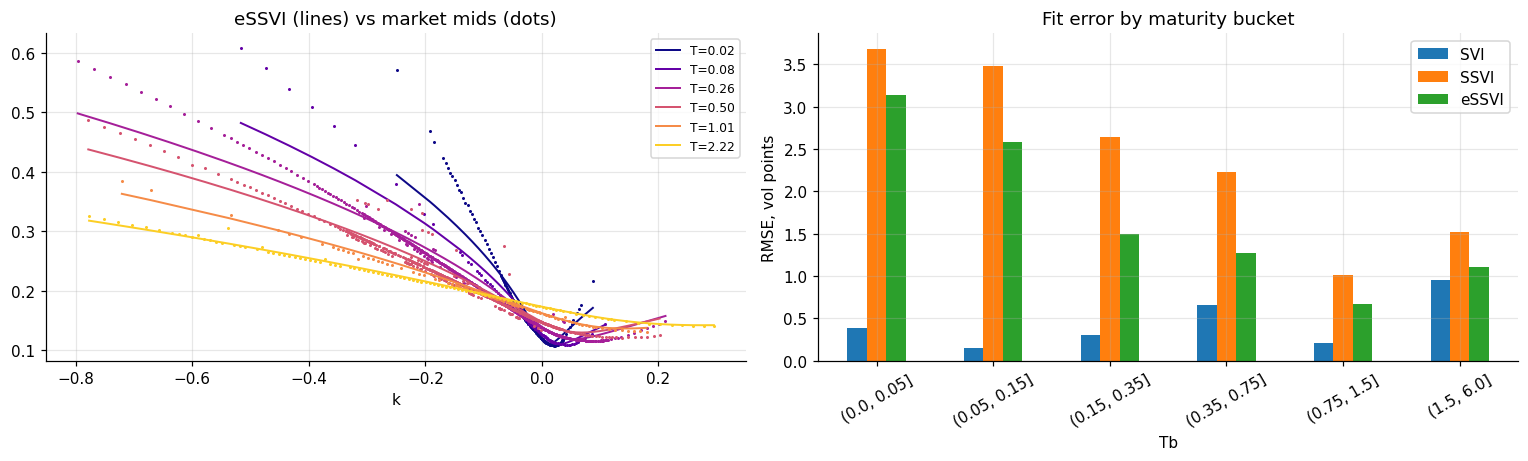

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(14, 4.3))
for e, c in zip(show, plt.cm.plasma(np.linspace(0, .9, len(show)))):
    g = fit_set[fit_set.expiry == e].sort_values("k")
    axs[0].plot(g.k, g.iv_mid, ".", ms=2, color=c)
    axs[0].plot(g.k, g.iv_essvi, "-", color=c, lw=1.3, label=f"T={g['T'].iloc[0]:.2f}")
axs[0].set_title("eSSVI (lines) vs market mids (dots)"); axs[0].set_xlabel("k"); axs[0].legend(fontsize=8)
err = fit_set.assign(Tb=pd.cut(fit_set["T"], [0, .05, .15, .35, .75, 1.5, 6]))
eb = err.groupby("Tb").apply(lambda d: pd.Series({m: 100*np.sqrt(np.mean((d[c]-d.iv_mid)**2)) for m, c in
                                                  [("SVI", "iv_svi"), ("SSVI", "iv_ssvi"), ("eSSVI", "iv_essvi")]}))
eb.plot.bar(ax=axs[1]); axs[1].set_ylabel("RMSE, vol points"); axs[1].set_title("Fit error by maturity bucket")
axs[1].tick_params(axis="x", rotation=30)
plt.tight_layout(); plt.show()

*Verification note:* the butterfly condition holds with a wide margin ($\min g>0$). The calendar condition is
enforced on a 61-point grid, so a few microscopic crossings (~$10^{-5}$ in total variance, about 1 % of a
typical ATM $w$) survive *between* grid points on the far wings. A production calibrator would use a denser
grid or the analytic crossing conditions of Hendriks & Martini.

**Trade-off.** Global SSVI gives up a lot of accuracy, mostly at the short end, where a single $\rho$
cannot fit both the steep short-dated skew and the gentler long-dated one. eSSVI improves the medium and
long end but still misses the short end by 2–3 vol points. This is a limit of the **SSVI slice family itself**, not of
the arbitrage constraints: fitting one SSVI slice to a 1-week smile with *no* constraints at all (and even with
θ free) still leaves ≈2.3 vol points of error. An SSVI slice is a 3-parameter sub-family of SVI, and it
cannot produce the very convex put wing *and* the flat call wing of a short-dated SPX smile at once.
Unconstrained SVI is the most accurate, because it spends its extra freedom partly on genuine shape and
partly on noise and arbitrage. The practical recipe on desks is therefore a hybrid: an arbitrage-free SSVI
backbone, with SVI slices constrained to stay above/below their neighbours (Gatheral–Jacquier §5). In practice desks often use SSVI as a **prior/regulariser** and
then add slice-level corrections (e.g. extended SSVI with $\rho(\theta)$, or constrained SVI
slices that must stay above the SSVI lower slice).

## 7. Risk-neutral densities (Breeden–Litzenberger)
Breeden & Litzenberger (1978): $q_T(K)=\frac{1}{D_T}\frac{\partial^2 C}{\partial K^2}$. We compute it by
finite differences on Black-76 prices generated from the fitted surface. A negative density is the
direct picture of butterfly arbitrage.

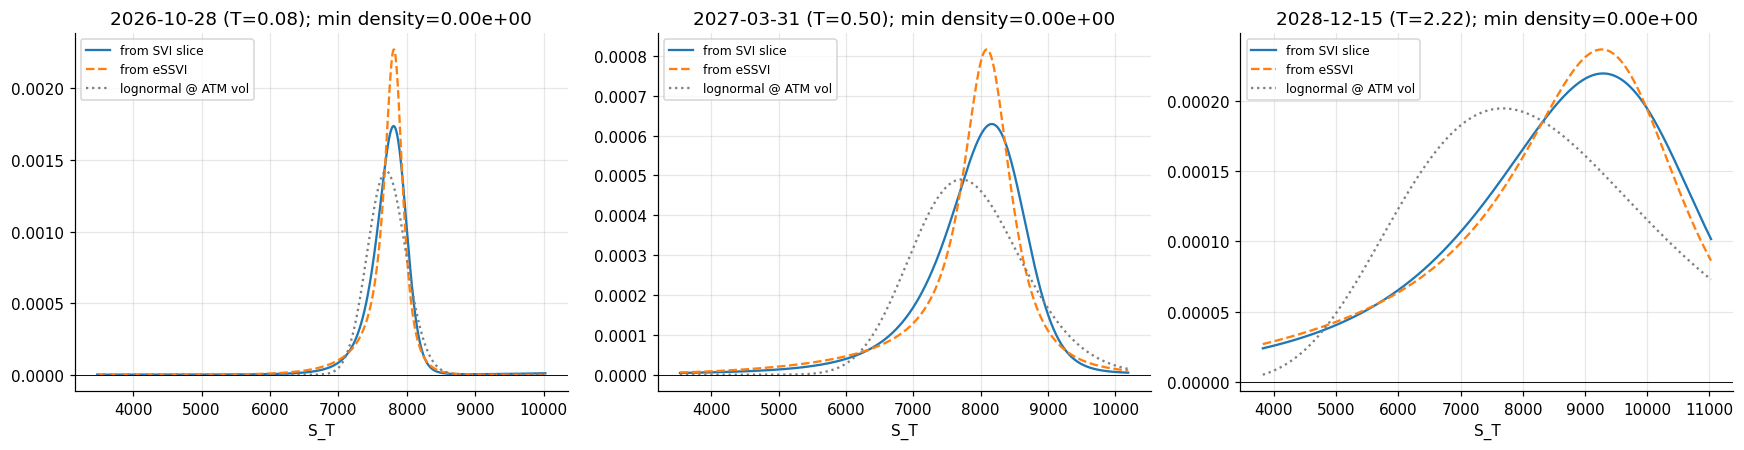

In [17]:
def density_from_w(wfun, F, T, D, K):
    ivs = np.sqrt(np.maximum(wfun(np.log(K / F)), 1e-12) / T)
    C = black76(F, K, T, ivs, D, True)
    h = K[1] - K[0]
    return (C[2:] - 2 * C[1:-1] + C[:-2]) / h ** 2 / D, K[1:-1]


fig, axs = plt.subplots(1, 3, figsize=(16, 4.2))
for ax, e in zip(axs, [show[1], show[3], show[5]]):
    F, D, T = fwd.loc[e, ["F", "D", "T"]]
    K = np.linspace(F * 0.45, F * 1.3, 1500)
    d1, Kd = density_from_w(lambda k: svi_w(svi[e]["params"], k), F, T, D, K)
    d2, _ = density_from_w(lambda k: essvi_w(k, theta_map[e], *essvi[e]), F, T, D, K)
    ax.plot(Kd, d1, label="from SVI slice"); ax.plot(Kd, d2, "--", label="from eSSVI")
    lognorm_sig = np.sqrt(theta_map[e] / T)
    ax.plot(Kd, norm.pdf(np.log(Kd / F) / (lognorm_sig * np.sqrt(T)) + 0.5 * lognorm_sig * np.sqrt(T)) /
            (Kd * lognorm_sig * np.sqrt(T)), ":", color="grey", label="lognormal @ ATM vol")
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{e} (T={T:.2f}); min density={min(d1.min(), 0):.2e}")
    ax.set_xlabel("S_T"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

The market density has a **fat left tail** and is **negatively skewed** compared with the lognormal
at the same ATM vol; this is the skew in probability space. It's also why a 25 % crash is
priced as far more likely than Black–Scholes would say.

## 8. A monitoring dashboard
The steps above can be packaged into a single function `surface_monitor(chain)` that returns a
per-expiry health table and a dashboard figure. On a live feed you'd call it on a timer and
alert when (a) an *executable* violation appears with edge > fees, (b) the SVI fit error jumps
(a stale or bad quote), or (c) surface summary statistics (ATM vol, skew, curvature, term slope) move by more
than *n* standard deviations of their recent history.

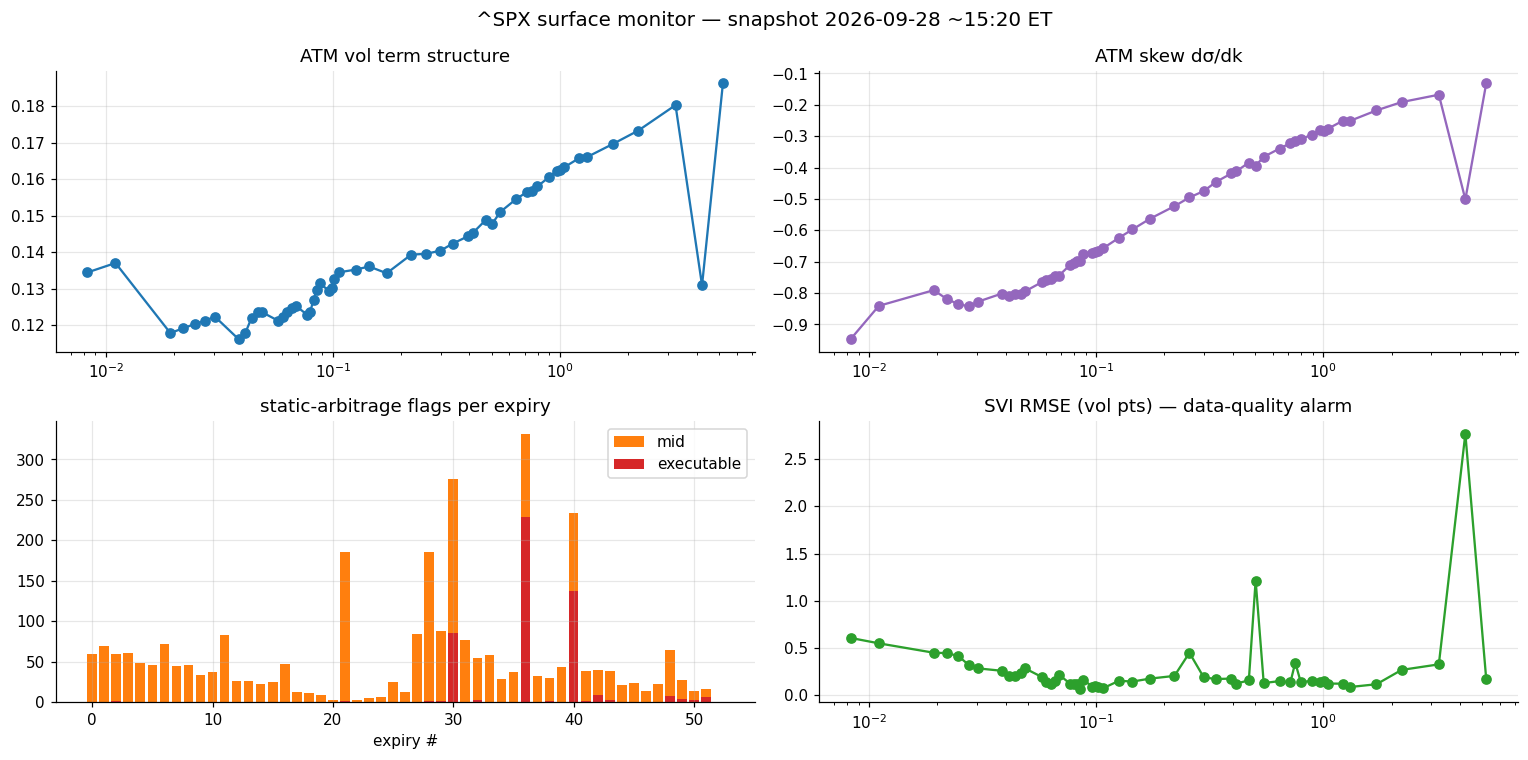

,T,n_quotes,atm_vol,atm_skew,curvature,svi_rmse,min_g,mid_viol,exec_viol,max_exec_edge
2026-10-01,0.0083,186.0000,0.1344,-0.9468,0.1852,0.6058,-0.0077,59.0000,0.0000,-0.0250
2026-10-08,0.0275,165.0000,0.1212,-0.8422,0.2202,0.3192,0.0217,46.0000,0.0000,-0.0500
2026-10-15,0.0467,141.0000,0.1236,-0.8036,0.2748,0.2327,0.0534,37.0000,0.0000,-0.1000
2026-10-22,0.0658,114.0000,0.1246,-0.7447,0.2902,0.1536,0.0660,25.0000,0.0000,-0.1250
2026-10-29,0.0850,62.0000,0.1296,-0.6976,0.3010,0.0607,0.0810,3.0000,0.0000,-0.2000
2026-11-06,0.1069,122.0000,0.1345,-0.6580,0.3079,0.0715,0.0916,25.0000,0.0000,-0.2000
2026-12-31,0.2576,566.0000,0.1395,-0.4953,0.3573,0.4487,0.0222,276.0000,85.0000,47.3500
2027-03-19,0.4706,200.0000,0.1487,-0.3840,0.3535,0.1562,0.1155,37.0000,0.0000,-0.1000
2027-06-30,0.7535,373.0000,0.1568,-0.3155,0.3803,0.3451,0.1504,234.0000,137.0000,59.5500
2027-10-15,1.0459,128.0000,0.1632,-0.2769,0.3337,0.1225,0.1850,24.0000,0.0000,-0.5333


In [18]:
def surface_monitor(chain: pd.DataFrame, underlying: str, plot=True, rate_fn=None):
    c = chain[chain.underlying == underlying]
    qx = clean_chain(c)
    fw, _ = forwards_and_discounts(qx, rate_fn=rate_fn)
    ivx = build_iv_table(qx, fw)
    ivx = ivx[(ivx.k > -0.8) & (ivx.k < 0.3)]
    vbx = check_vertical_butterfly(qx, fw)
    rows = {}
    for e, g in ivx.groupby("expiry"):
        g = g.sort_values("k")
        if len(g) < 10:
            continue
        T = g["T"].iloc[0]
        sw = np.maximum((g.iv_ask - g.iv_bid).fillna(0.05).values, 0.002) * 2 * g.iv_mid.values * T
        p = fit_svi(g.k.values, g.w.values, (1 / sw) / (1 / sw).mean(), T)
        w0, w1, w2 = svi_derivs(p, 0.0)
        v = vbx[vbx.expiry == e]
        rows[e] = dict(T=T, n_quotes=len(g), atm_vol=np.sqrt(w0 / T),
                       atm_skew=w1 / (2 * np.sqrt(w0 * T)),          # d sigma / dk at the money
                       curvature=w2, svi_rmse=100 * np.sqrt(np.mean((np.sqrt(svi_w(p, g.k.values) / T) - g.iv_mid) ** 2)),
                       min_g=durrleman_g(p, np.linspace(-0.8, 0.3, 200)).min(),
                       mid_viol=int(v.mid_viol.sum()), exec_viol=int(v.exec_viol.sum()),
                       max_exec_edge=v.exec_edge.max())
    tab = pd.DataFrame(rows).T.sort_values("T")
    if plot:
        fig, axs = plt.subplots(2, 2, figsize=(14, 7))
        fig.suptitle(f"{underlying} surface monitor — snapshot {chain.snapshot.iloc[0]}", fontsize=13)
        axs[0, 0].plot(tab["T"], tab.atm_vol, "o-"); axs[0, 0].set_xscale("log"); axs[0, 0].set_title("ATM vol term structure")
        axs[0, 1].plot(tab["T"], tab.atm_skew, "o-", color="tab:purple"); axs[0, 1].set_xscale("log")
        axs[0, 1].set_title("ATM skew dσ/dk")
        axs[1, 0].bar(range(len(tab)), tab.mid_viol, color="tab:orange", label="mid")
        axs[1, 0].bar(range(len(tab)), tab.exec_viol, color="tab:red", label="executable")
        axs[1, 0].set_title("static-arbitrage flags per expiry"); axs[1, 0].legend(); axs[1, 0].set_xlabel("expiry #")
        axs[1, 1].semilogx(tab["T"], tab.svi_rmse, "o-", color="tab:green"); axs[1, 1].set_title("SVI RMSE (vol pts) — data-quality alarm")
        plt.tight_layout(); plt.show()
    return tab


mon_spx = surface_monitor(raw, "^SPX")
mon_spx.iloc[::5]

### 8.1 A contrast: SPY (American-style, single stock-like)
Running the same monitor on SPY shows why the choice of underlying matters: SPY options are
**American** (early exercise), so European formulas and parity are only approximately right. Deep ITM
puts carry early-exercise premium, and around ex-dividend dates calls do too. The monitor
flags this as higher SVI error and more "violations" — a model-mismatch warning, not arbitrage. This is
why SPX (European, cash-settled) is the standard index for surface work.

In [19]:
raw_spy = raw.assign(contractSymbol=raw.contractSymbol.str.replace("^SPY", "SPYW", regex=True))  # single root
mon_spy = surface_monitor(raw_spy, "SPY", plot=False, rate_fn=rate_curve)   # European parity fails for American puts → reuse SPX rates
pd.DataFrame({"SPX": mon_spx[["svi_rmse", "mid_viol", "exec_viol"]].astype(float).median(),
              "SPY": mon_spy[["svi_rmse", "mid_viol", "exec_viol"]].astype(float).median()}).rename(
    index=lambda s: "median " + s)

,SPX,SPY
median svi_rmse,0.1647,0.2320
median mid_viol,37.0000,27.0000
median exec_viol,0.0000,0.0000


### 8.2 Running it in real time
The monitor is a pure function of a chain snapshot, so a real-time version is a loop around a data
feed. A minimal design (not executed here, because it needs a live feed):

```python
history = []
while market_open():
    chain = feed.snapshot("SPX")                 # e.g. OPRA via Databento `OPRA.PILLAR`, or a broker API
    tab   = surface_monitor(chain, "SPX", plot=False)
    history.append(tab.assign(ts=pd.Timestamp.now()))
    z = zscore_vs_recent(history, ["atm_vol", "atm_skew", "svi_rmse"])   # rolling-window z-scores
    if (tab.max_exec_edge > FEE_PER_LEG * 4).any() or (z.abs() > 4).any().any():
        alert(tab, z)
    publish_to_dashboard(tab)                    # Streamlit / Dash / Grafana
    time.sleep(5)
```
Practical points: use **synchronous** quotes (an NBBO snapshot at one timestamp, or better, a
consolidated OPRA feed), apply fees and minimum size before calling anything "arbitrage", and
refit SSVI incrementally (warm-start from the previous parameters). A full chain refit takes
well under a second, as timed above.

## 9. Strengths, weaknesses and extensions

**Strengths of the approach**
* Model-free checks come first: vertical/butterfly/calendar tests on quotes need no model and
  separate *data inconsistencies* from *model errors*.
* Parity-implied forwards/discounts make the surface internally consistent, with no dividend or
  rate assumptions.
* SVI slices fit almost to within the bid–ask spread; SSVI/eSSVI give a guaranteed arbitrage-free
  surface with very few parameters, so they're cheap to store, interpolate and extrapolate.
* Bid/ask-aware checks avoid the most common mistake in amateur "arbitrage detection": reporting
  mid-price violations as trading opportunities.

**Weaknesses / caveats**
* A single, non-synchronous retail snapshot. Real monitoring needs time-stamped, synchronous
  NBBO data; Yahoo quotes can be seconds to minutes apart.
* Treating all expiries as 16:00 PM-settled mis-states $T$ for AM-settled monthlies by up to
  ~6.5 h, which matters only for the shortest maturities.
* SVI slices can violate calendar/butterfly conditions; SSVI can't fit the short end well (one global $\rho$);
  eSSVI's sequential calibration is path-dependent (a bad early slice constrains all later ones).
* Static arbitrage is necessary but not sufficient for a *good* surface: a smooth, arbitrage-free
  surface can still misprice path-dependent exotics (that needs dynamics — local/stochastic vol).
* Dividends are implicit in $F_T$; discrete dividends create small kinks that SSVI ignores.

**Extensions**
* Arbitrage-free SVI calibration (Gatheral–Jacquier §5) or eSSVI with maturity-dependent $\rho$ (Hendriks & Martini 2019).
* Dupire local volatility from the SSVI surface — arbitrage-freeness guarantees positive local variance.
* A time series of snapshots: PCA of daily surface changes (level / skew / term-structure factors).
* Compare against the generative arbitrage-free surfaces in `../papers_implemented/Milena_Vuletić/`.

**References.** Gatheral, *The Volatility Surface* (2006); Gatheral & Jacquier, "Arbitrage-free SVI
volatility surfaces", *Quantitative Finance* (2014); Carr & Madan, "A note on sufficient conditions for no
arbitrage" (2005); Roper, "Arbitrage free implied volatility surfaces" (2010); Breeden & Litzenberger (1978).